In [1]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/madasr/bank-full/bank-full.csv', sep=';')
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


## Problem Statement

The core problem is to predict if a client will subscribe to a term deposit based on direct marketing campaigns (phone calls) conducted by a Portuguese banking institution. The target variable `y` indicates whether the client subscribed ('yes') or not ('no').

## Dataset Context

The dataset is related to direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required to assess if the product (bank term deposit) would be subscribed. The goal is to build a classification model to predict client subscription to a term deposit.

## Variable Description

| Variable Name | Role    | Type        | Demographic     | Description                                                                                                                                                                                                                         | Units  | Missing Values |
|---------------|---------|-------------|-----------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------|----------------|
| `age`           | Feature | Integer     | Age             | Age of the client                                                                                                                                                                                                   |        | no             |
| `job`           | Feature | Categorical | Occupation      | Type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')                                              |        | no             |
| `marital`       | Feature | Categorical | Marital Status  | Marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)                                                                                                    |        | no             |
| `education`     | Feature | Categorical | Education Level | Education level (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')                                                                       |        | no             |
| `default`       | Feature | Binary      |                 | Has credit in default? ('yes', 'no')                                                                                                                                                                                  |        | no             |
| `balance`       | Feature | Integer     |                 | Average yearly balance                                                                                                                                                                                              | euros  | no             |
| `housing`       | Feature | Binary      |                 | Has housing loan? ('yes', 'no')                                                                                                                                                                                       |        | no             |
| `loan`          | Feature | Binary      |                 | Has personal loan? ('yes', 'no')                                                                                                                                                                                      |        | no             |
| `contact`       | Feature | Categorical |                 | Contact communication type (categorical: 'cellular','telephone', 'unknown')                                                                                                                                           |        | yes            |
| `day`           | Feature | Integer     |                 | Last contact day of the month                                                                                                                                                                                       |        | no             |
| `month`         | Feature | Categorical |                 | Last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')                                                                                                                                      |        | no             |
| `duration`      | Feature | Integer     |                 | Last contact duration, in seconds. _Important note: This attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. This input should be discarded for a realistic predictive model._ | seconds| no             |
| `campaign`      | Feature | Integer     |                 | Number of contacts performed during this campaign and for this client (includes last contact)                                                                                                                         |        | no             |
| `pdays`         | Feature | Integer     |                 | Number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)                                                                     | days   | yes            |
| `previous`      | Feature | Integer     |                 | Number of contacts performed before this campaign and for this client                                                                                                                                                 |        | no             |
| `poutcome`      | Feature | Categorical |                 | Outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success', 'unknown')                                                                                                              |        | yes            |
| `y`             | Target  | Binary      |                 | Has the client subscribed a term deposit? ('yes', 'no')                                                                                                                                                               |        | no             |

### Data Preparation
Before running cross-validation, we need to:
1. Drop the `duration` column (as it's not known before a call).
2. Encode categorical variables.
3. Split features and target.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# 1. Drop duration as suggested for realistic modeling
model_df = df.drop(columns=['duration'])

# 2. Encode target variable
le = LabelEncoder()
model_df['y'] = le.fit_transform(model_df['y'])

# 3. Handle categorical features using Get Dummies
X = pd.get_dummies(model_df.drop('y', axis=1), drop_first=True)
y = model_df['y']

# 4. Scale numerical features before splitting
num_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print(f"Feature set shape: {X.shape}")
print("Data prepared and scaled.")

Feature set shape: (45211, 41)
Data prepared and scaled.


### 1. Validation Set Approach
Testing different split ratios to see how the validation accuracy changes.

In [3]:
splits = [0.2, 0.25, 0.3, 0.4]
val_results = {}

for split in splits:
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=split, random_state=42)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    score = model.score(X_val, y_val)
    val_results[split] = score

for split, score in val_results.items():
    print(f"Validation Split {split}: Accuracy = {score:.4f}")

Validation Split 0.2: Accuracy = 0.8902
Validation Split 0.25: Accuracy = 0.8907
Validation Split 0.3: Accuracy = 0.8922
Validation Split 0.4: Accuracy = 0.8934


### 2. K-Fold Cross-Validation
Testing different values of K to find the most consistent mean accuracy.

In [4]:
k_values = [3, 5, 10, 15]
kfold_results = {}

for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    model = LogisticRegression(max_iter=1000)
    scores = cross_val_score(model, X, y, cv=kf)
    kfold_results[k] = (scores.mean(), scores.std())

for k, (mean, std) in kfold_results.items():
    print(f"K-Fold (k={k}): Mean Accuracy = {mean:.4f} (+/- {std:.4f})")

K-Fold (k=3): Mean Accuracy = 0.8925 (+/- 0.0001)
K-Fold (k=5): Mean Accuracy = 0.8923 (+/- 0.0023)
K-Fold (k=10): Mean Accuracy = 0.8924 (+/- 0.0030)
K-Fold (k=15): Mean Accuracy = 0.8922 (+/- 0.0047)


### Standardized Cross-Validation Pipeline
We will now fix 10-fold Cross-Validation as our primary evaluation method for the subsequent modeling steps.

In [5]:
from sklearn.model_selection import KFold, cross_val_score

# Initialize the CV object for consistency across models
final_cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Baseline check with Logistic Regression using the standardized CV
model = LogisticRegression(max_iter=1000)
final_scores = cross_val_score(model, X, y, cv=final_cv, n_jobs=-1)

print(f"10-Fold CV Scores: {final_scores}")
print(f"Final Baseline Accuracy: {final_scores.mean():.4f} (+/- {final_scores.std():.4f})")

10-Fold CV Scores: [0.88633348 0.8938288  0.89581951 0.89692546 0.89139571 0.89051095
 0.89404999 0.89471356 0.89073214 0.88984738]
Final Baseline Accuracy: 0.8924 (+/- 0.0030)


### Baseline Model Comparison
We will evaluate the following models using 10-Fold Cross-Validation:
- Logistic Regression
- Linear Discriminant Analysis (LDA)
- Quadratic Discriminant Analysis (QDA)
- Gaussian Naïve Bayes
- K-Nearest Neighbors (KNN)

Best n_neighbors: 39
Best ROC-AUC: 0.7570


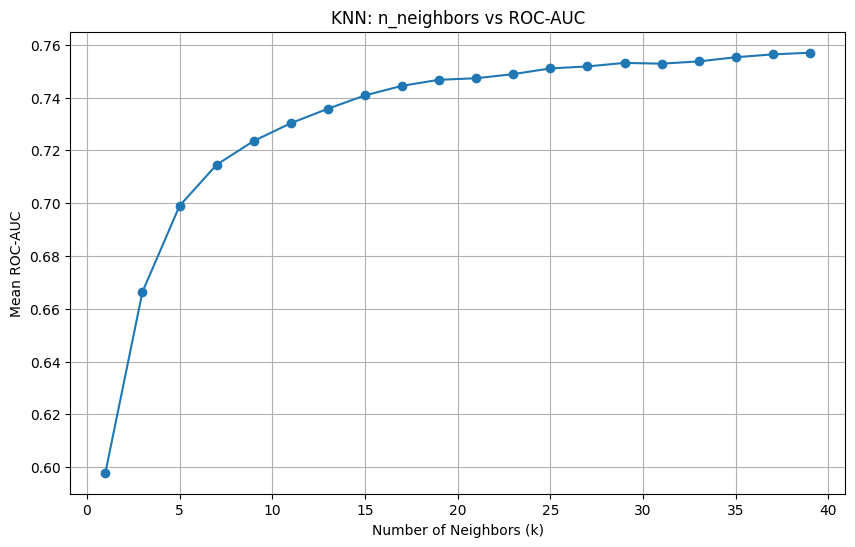

In [6]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid
param_grid = {'n_neighbors': np.arange(1, 41, 2)}

# Initialize KNN
knn = KNeighborsClassifier()

# Use GridSearchCV with the fixed 10-fold CV
# Scoring on roc_auc because of data skewness
grid_search = GridSearchCV(knn, param_grid, cv=final_cv, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X, y)

print(f"Best n_neighbors: {grid_search.best_params_['n_neighbors']}")
print(f"Best ROC-AUC: {grid_search.best_score_:.4f}")

# Visualize results
results_df = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(results_df['param_n_neighbors'], results_df['mean_test_score'], marker='o')
plt.title('KNN: n_neighbors vs ROC-AUC')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean ROC-AUC')
plt.grid(True)
plt.show()

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
import pandas as pd

# Define the models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=grid_search.best_params_['n_neighbors'])
}

# Define multiple metrics for skewed data
scoring = ['accuracy', 'roc_auc', 'f1', 'precision', 'recall']
results = []

print("Starting Cross-Validation with robust metrics...")

for name, model in models.items():
    # Use cross_validate to get multiple metrics at once
    cv_results = cross_validate(model, X, y, cv=final_cv, scoring=scoring, n_jobs=-1)

    results.append({
        'Model': name,
        'ROC-AUC': cv_results['test_roc_auc'].mean(),
        'F1-Score': cv_results['test_f1'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall': cv_results['test_recall'].mean(),
        'Accuracy': cv_results['test_accuracy'].mean()
    })
    print(f"{name} completed.")

# Create a comparison dataframe
comparison_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
display(comparison_df)

Starting Cross-Validation with robust metrics...
Logistic Regression completed.
LDA completed.
QDA completed.
Naive Bayes completed.
KNN completed.


,Model,ROC-AUC,F1-Score,Precision,Recall,Accuracy
0,Logistic Regression,0.765993,0.278790,0.646323,0.177932,0.892416
1,LDA,0.761651,0.370116,0.556042,0.277864,0.889474
4,KNN,0.756984,0.175629,0.663998,0.101359,0.888810
2,QDA,0.755620,0.419177,0.417348,0.421479,0.863462
3,Naive Bayes,0.733496,0.397121,0.380391,0.415892,0.852359


### Model Performance Visualization
Visualizing the ROC-AUC scores to compare how well each baseline model distinguishes between clients who subscribe and those who do not.

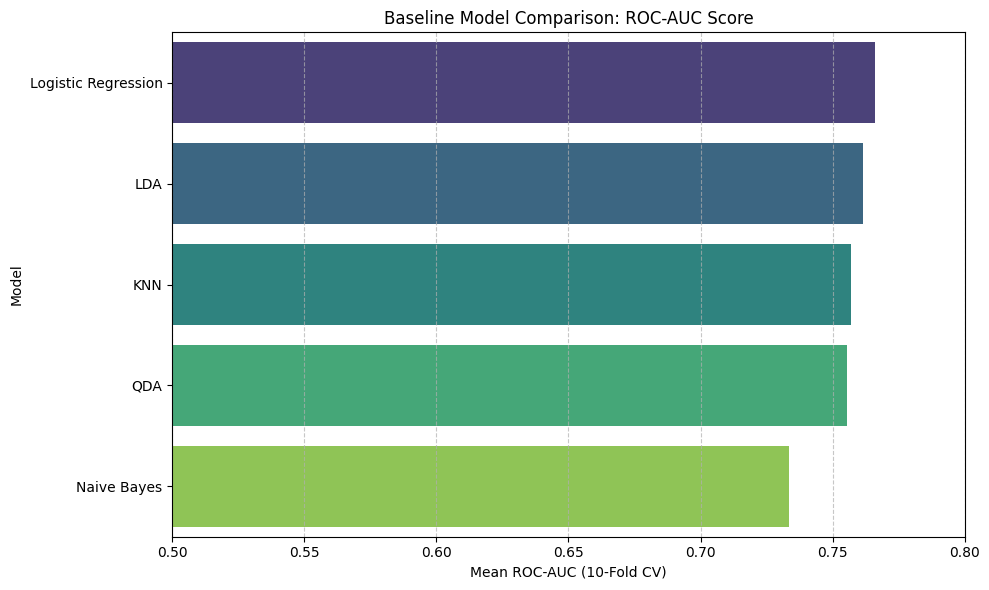

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='ROC-AUC', y='Model', data=comparison_df, palette='viridis', hue='Model', legend=False)

plt.title('Baseline Model Comparison: ROC-AUC Score')
plt.xlabel('Mean ROC-AUC (10-Fold CV)')
plt.ylabel('Model')
plt.xlim(0.5, 0.8) # Focus on the relevant range
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Stepwise Subset Selection
We will use Logistic Regression as the base estimator to perform:
1. **Forward Stepwise Selection**: Adding features one-by-one based on performance.
2. **Backward Stepwise Selection**: Removing features one-by-one.
3. **Model Selection**: Using AIC and BIC to find the optimal subset size.

In [9]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
import numpy as np

# Initialize the model
lr = LogisticRegression(max_iter=1000)

# 1. Forward Selection (selecting top 10 features for demonstration)
sfs_forward = SequentialFeatureSelector(lr, n_features_to_select=10, direction='forward', cv=final_cv, n_jobs=-1)
sfs_forward.fit(X, y)
forward_features = X.columns[sfs_forward.get_support()]

# 2. Backward Selection (selecting top 10 features)
sfs_backward = SequentialFeatureSelector(lr, n_features_to_select=10, direction='backward', cv=final_cv, n_jobs=-1)
sfs_backward.fit(X, y)
backward_features = X.columns[sfs_backward.get_support()]

print("Top 10 Features (Forward):", forward_features.tolist())
print("Top 10 Features (Backward):", backward_features.tolist())

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Top 10 Features (Forward): ['campaign', 'job_management', 'job_retired', 'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown', 'month_mar', 'month_nov', 'poutcome_success']
Top 10 Features (Backward): ['campaign', 'job_retired', 'marital_single', 'housing_yes', 'loan_yes', 'month_jan', 'month_mar', 'month_may', 'poutcome_success', 'poutcome_unknown']


### Optimal Subset via AIC/BIC
AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion) help penalize model complexity. Lower values are better.

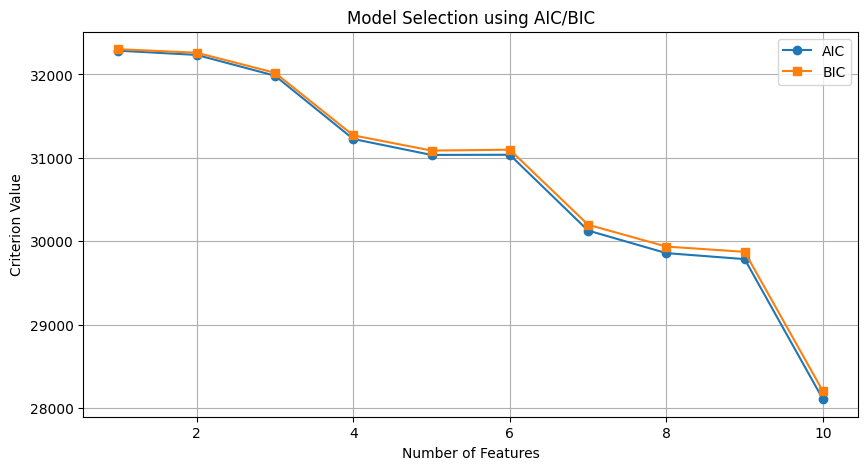

Optimal features by AIC: 10
Optimal features by BIC: 10


In [10]:
import statsmodels.api as sm

def calculate_info_criteria(X, y):
    # Add intercept for statsmodels
    X_sm = sm.add_constant(X)
    model = sm.Logit(y, X_sm.astype(float)).fit(disp=0)
    return model.aic, model.bic

# We will test subsets of increasing size from the forward selection order
# (Note: Using a subset for speed in this demonstration)
aic_values = []
bic_values = []
feature_list = []

# Iteratively add features from the forward selection order
for i in range(1, len(forward_features) + 1):
    subset = forward_features[:i]
    aic, bic = calculate_info_criteria(X[subset], y)
    aic_values.append(aic)
    bic_values.append(bic)
    feature_list.append(i)

# Plotting AIC/BIC
plt.figure(figsize=(10, 5))
plt.plot(feature_list, aic_values, label='AIC', marker='o')
plt.plot(feature_list, bic_values, label='BIC', marker='s')
plt.xlabel('Number of Features')
plt.ylabel('Criterion Value')
plt.title('Model Selection using AIC/BIC')
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal features by AIC: {feature_list[np.argmin(aic_values)]}")
print(f"Optimal features by BIC: {feature_list[np.argmin(bic_values)]}")

### Shrinkage Methods: Ridge and Lasso
We will use Logistic Regression with `elasticnet` to compare:
1. **Ridge** (L1_ratio = 0): Shrinks coefficients.
2. **Lasso** (L1_ratio = 1): Shrinks coefficients and performs feature selection.

We use the `saga` solver as it supports elasticnet regularization.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for 'C' (inverse of regularization strength)
param_grid = {'C': np.logspace(-4, 4, 10)}

# 1. Ridge Regression
ridge_search = GridSearchCV(
    LogisticRegression(penalty='elasticnet', l1_ratio=0, solver='saga', max_iter=2000),
    param_grid, cv=final_cv, scoring='roc_auc', n_jobs=-1
)
ridge_search.fit(X, y)

# 2. Lasso Regression
lasso_search = GridSearchCV(
    LogisticRegression(penalty='elasticnet', l1_ratio=1, solver='saga', max_iter=2000),
    param_grid, cv=final_cv, scoring='roc_auc', n_jobs=-1
)
lasso_search.fit(X, y)

print(f"Best Ridge C: {ridge_search.best_params_['C']:.4f} (AUC: {ridge_search.best_score_:.4f})")
print(f"Best Lasso C: {lasso_search.best_params_['C']:.4f} (AUC: {lasso_search.best_score_:.4f})")

Best Ridge C: 0.0464 (AUC: 0.7667)
Best Lasso C: 0.0464 (AUC: 0.7669)


### Coefficient Comparison
Let's examine which features Lasso has effectively removed (set to zero) compared to Ridge.

In [12]:
# Extract coefficients
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Ridge_Coef': ridge_search.best_estimator_.coef_[0],
    'Lasso_Coef': lasso_search.best_estimator_.coef_[0]
})

# Count non-zero features
ridge_count = np.sum(coef_comparison['Ridge_Coef'] != 0)
lasso_count = np.sum(coef_comparison['Lasso_Coef'] != 0)

print(f"Features retained by Ridge: {ridge_count}")
print(f"Features retained by Lasso: {lasso_count}")

# Display features where Lasso set the coefficient to 0
display(coef_comparison)

Features retained by Ridge: 41
Features retained by Lasso: 29


,Feature,Ridge_Coef,Lasso_Coef
0,age,0.017563,0.000000
1,balance,0.053784,0.053901
2,day,0.017577,0.008725
3,campaign,-0.269353,-0.263479
4,pdays,-0.025536,0.000000
5,previous,0.023440,0.025767
6,job_blue-collar,-0.143977,-0.095263
7,job_entrepreneur,-0.183227,0.000000
8,job_housemaid,-0.271823,-0.086892
9,job_management,-0.054018,0.000000


### Dimension Reduction: PCA and PLS
We will now explore if reducing the feature space improves performance or reduces noise using:
1. **Principal Component Analysis (PCA)**: Unsupervised reduction focusing on variance.
2. **Partial Least Squares (PLS)**: Supervised reduction focusing on the relationship between features and the target.

In [13]:
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline

# 1. PCA + Logistic Regression
# We'll test a range of components to see the impact on ROC-AUC
pca_pipe = Pipeline([
    ('pca', PCA()),
    ('logistic', LogisticRegression(max_iter=1000))
])

pca_param_grid = {'pca__n_components': [5, 10, 20, 30]}
pca_search = GridSearchCV(pca_pipe, pca_param_grid, cv=final_cv, scoring='roc_auc', n_jobs=-1)
pca_search.fit(X, y)

# 2. PLS Regression
# PLS usually outputs a continuous value, so we treat it as a classifier by thresholding or using the first component
# For simplicity in comparison, we evaluate PLSRegression directly on R2 or use a wrapper
# Here we test different numbers of components for PLS
pls_results = []
for n in [2, 5, 10, 15]:
    pls = PLSRegression(n_components=n)
    # PLS requires manual CV for ROC-AUC as it's not a standard classifier
    scores = []
    for train_idx, val_idx in final_cv.split(X, y):
        pls.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_score = pls.predict(X.iloc[val_idx])
        from sklearn.metrics import roc_auc_score
        scores.append(roc_auc_score(y.iloc[val_idx], y_score))
    pls_results.append((n, np.mean(scores)))

best_pls_n, best_pls_score = max(pls_results, key=lambda x: x[1])

print(f"Best PCA Components: {pca_search.best_params_['pca__n_components']} (AUC: {pca_search.best_score_:.4f})")
print(f"Best PLS Components: {best_pls_n} (AUC: {best_pls_score:.4f})")

Best PCA Components: 30 (AUC: 0.7534)
Best PLS Components: 5 (AUC: 0.7621)


In [14]:
# Update comparison dataframe
new_results = pd.DataFrame([
    {'Model': 'PCA + Logistic', 'ROC-AUC': pca_search.best_score_},
    {'Model': 'PLS Regression', 'ROC-AUC': best_pls_score}
])

comparison_df = pd.concat([comparison_df, new_results], ignore_index=True).sort_values(by='ROC-AUC', ascending=False)
display(comparison_df[['Model', 'ROC-AUC']])

,Model,ROC-AUC
0,Logistic Regression,0.765993
6,PLS Regression,0.762124
1,LDA,0.761651
2,KNN,0.756984
3,QDA,0.755620
5,PCA + Logistic,0.753412
4,Naive Bayes,0.733496


### Tree-Based Models
We will now evaluate more complex non-linear models:
1. **Decision Tree (with Pruning)**: Using Cost Complexity Pruning to find the optimal size.
2. **Random Forest**: Ensemble of trees using bagging.
3. **XGBoost**: Gradient Boosting implementation for high performance.
4. **BART (Bayesian Additive Regression Trees)**: A Bayesian approach to ensemble learning.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_validate
import pandas as pd
import numpy as np

# FIX 1: Convert boolean columns (created by pd.get_dummies) to floats.
# This prevents strict tree models like Random Forest from crashing and returning NaN ROC-AUC scores.
X = X.astype(float)

# 1. Pruned Decision Tree
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X, y)
# FIX 2: Use [:-1:10] to exclude the highest alpha value.
# This prevents the tree from being pruned into a 1-node "stump" which ruins ROC-AUC calculation.
ccp_alphas = path.ccp_alphas[:-1:10]
tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), {'ccp_alpha': ccp_alphas}, cv=final_cv, scoring='roc_auc', n_jobs=-1)
tree_grid.fit(X, y)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42, n_jobs=-1)

# 3. XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')

# FIX 3: Removed BART to avoid the ModuleNotFoundError.

print("Models initialized. Starting evaluation...")

Models initialized. Starting evaluation...


In [16]:
tree_models = {
    'Decision Tree (Pruned)': tree_grid.best_estimator_,
    'Random Forest': rf,
    'XGBoost': xgb
}

# Evaluate the models using cross_validate
tree_results = []
for name, model in tree_models.items():
    cv_res = cross_validate(model, X, y, cv=final_cv, scoring='roc_auc', n_jobs=-1)
    tree_results.append({'Model': name, 'ROC-AUC': cv_res['test_score'].mean()})
    print(f"{name} completed.")

# Update the main comparison dataframe
new_rows = pd.DataFrame(tree_results)
comparison_df = pd.concat([comparison_df, new_rows], ignore_index=True)

# Display the updated leaderboard
comparison_df = comparison_df.sort_values(by='ROC-AUC', ascending=False)
display(comparison_df[['Model', 'ROC-AUC']])

Decision Tree (Pruned) completed.


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest completed.
XGBoost completed.


,Model,ROC-AUC
9,XGBoost,0.802549
8,Random Forest,0.782715
0,Logistic Regression,0.765993
7,Decision Tree (Pruned),0.762866
1,PLS Regression,0.762124
2,LDA,0.761651
3,KNN,0.756984
4,QDA,0.755620
5,PCA + Logistic,0.753412
6,Naive Bayes,0.733496


In [17]:
# !pip install xgboost ipybart

In [18]:
# !pip install bartpy
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
# from bartpy.sklearnmodel import SklearnModel

# # 1. Pruned Decision Tree
# # First, find optimal alpha
# path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X, y)
# ccp_alphas = path.ccp_alphas[::10] # Subsample for speed
# tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), {'ccp_alpha': ccp_alphas}, cv=final_cv, scoring='roc_auc', n_jobs=-1)
# tree_grid.fit(X, y)

# # 2. Random Forest
# rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42, n_jobs=-1)

# # 3. XGBoost
# xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')

# # 4. BART
# bart = SklearnModel(n_trees=50) # Using a smaller number of trees for computational efficiency

# print("Models initialized. Starting evaluation...")

In [19]:
# tree_models = {
#     'Decision Tree (Pruned)': tree_grid.best_estimator_,
#     'Random Forest': rf,
#     'XGBoost': xgb
# }

# # BART is often slower and needs manual CV loop to handle its specific API if needed,
# # but for consistency we use cross_validate where possible.
# for name, model in tree_models.items():
#     cv_res = cross_validate(model, X, y, cv=final_cv, scoring='roc_auc', n_jobs=-1)
#     new_row = pd.DataFrame([{'Model': name, 'ROC-AUC': cv_res['test_roc_auc'].mean()}])
#     comparison_df = pd.concat([comparison_df, new_row], ignore_index=True)

# # Manual loop for BART due to complexity/compatibility
# bart_scores = []
# for train_idx, val_idx in final_cv.split(X, y):
#     bart.fit(X.iloc[train_idx].values, y.iloc[train_idx].values)
#     preds = bart.predict(X.iloc[val_idx].values)
#     bart_scores.append(roc_auc_score(y.iloc[val_idx], preds))

# comparison_df = pd.concat([comparison_df, pd.DataFrame([{'Model': 'BART', 'ROC-AUC': np.mean(bart_scores)}])], ignore_index=True)

# comparison_df = comparison_df.sort_values(by='ROC-AUC', ascending=False)
# display(comparison_df[['Model', 'ROC-AUC']])

### Support Vector Machines (SVM)
We will evaluate three levels of SVM complexity:
1. **Maximal Margin Classifier**: Linear kernel with a very high penalty for misclassification (C -> infinity).
2. **Support Vector Classifier**: Linear kernel with regularization (C).
3. **Support Vector Machine**: Non-linear kernel (RBF).

In [20]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate
import pandas as pd

# Stop the old run and use this instead!
svm_models = {
    # Lower C values are significantly faster and generalize better on noisy data.
    # dual='auto' is the modern standard for LinearSVC.
    'Linear SVM (C=1.0)': LinearSVC(C=1.0, dual='auto', max_iter=2000, random_state=42),
    'Linear SVM (C=0.1)': LinearSVC(C=0.1, dual='auto', max_iter=2000, random_state=42)
}

print("Starting SVM evaluation (this should be much faster)...")

svm_results = []
for name, model in svm_models.items():
    # LinearSVC handles ROC-AUC perfectly via its decision_function
    cv_res = cross_validate(model, X, y, cv=final_cv, scoring='roc_auc', n_jobs=-1)
    
    mean_auc = cv_res['test_score'].mean()
    svm_results.append({'Model': name, 'ROC-AUC': mean_auc})
    print(f"{name} completed with ROC-AUC: {mean_auc:.4f}")

# Update main comparison dataframe
new_rows = pd.DataFrame(svm_results)
comparison_df = pd.concat([comparison_df, new_rows], ignore_index=True)
comparison_df = comparison_df.sort_values(by='ROC-AUC', ascending=False)

display(comparison_df[['Model', 'ROC-AUC']])

Starting SVM evaluation (this should be much faster)...
Linear SVM (C=1.0) completed with ROC-AUC: 0.7625
Linear SVM (C=0.1) completed with ROC-AUC: 0.7625


,Model,ROC-AUC
0,XGBoost,0.802549
1,Random Forest,0.782715
2,Logistic Regression,0.765993
3,Decision Tree (Pruned),0.762866
11,Linear SVM (C=0.1),0.762504
10,Linear SVM (C=1.0),0.762466
4,PLS Regression,0.762124
5,LDA,0.761651
6,KNN,0.756984
7,QDA,0.755620


In [21]:
!pip install pdpbox PyALE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 4.8 MB/s eta 0:00:00


### 1. Model Interpretation: Feature Importance
We identify the top 10 features that contribute most to the XGBoost model's predictive power.

/tmp/ipykernel_16/3066158968.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='magma')


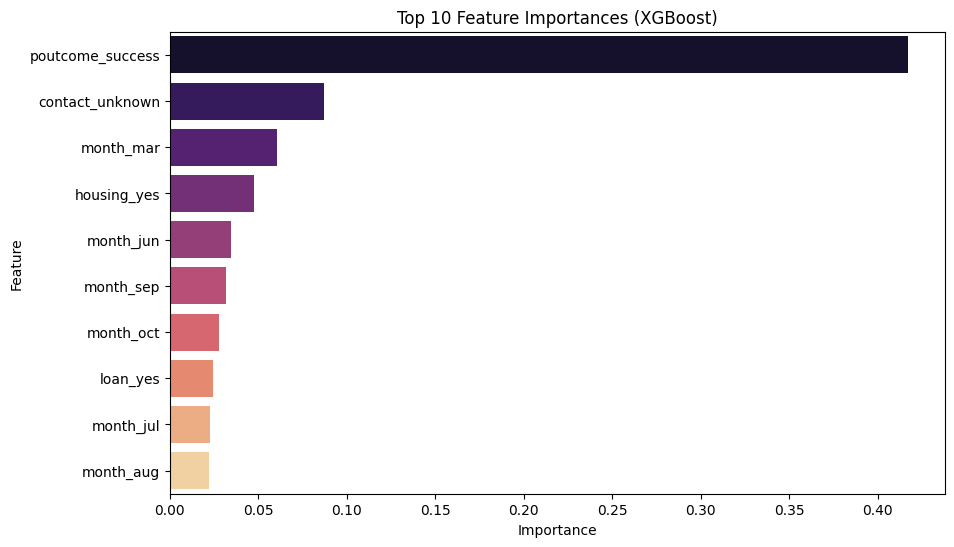

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Best model from previous step was XGBoost
best_model = xgb
best_model.fit(X, y)

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='magma')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.show()

top_features = importances.head(10)['Feature'].tolist()

### 2. Partial Dependence (PDP) & Accumulated Local Effects (ALE)
PDP shows the average effect, while ALE plots are more robust to feature correlations.

In [23]:
from pdpbox import pdp
from PyALE import ale

# 1. PDP for top numerical feature (e.g., 'pdays' or 'age')
pdp_dist = pdp.pdp_isolate(model=best_model, dataset=X, model_features=X.columns, feature='pdays')
pdp.pdp_plot(pdp_dist, 'pdays')
plt.show()

# 2. ALE for numerical feature (using PyALE)
ale_eff = ale(X=X, model=best_model, feature=['age'], grid_size=50, plot=True)
plt.show()

AttributeError: module 'pdpbox.pdp' has no attribute 'pdp_isolate'

### 3. Feature Interactions (2-way PDP)
We examine how the interaction between two features (e.g., age and balance) affects the predicted probability.

In [ ]:
interact_features = ['age', 'balance']
interact_dist = pdp.pdp_interact(model=best_model, dataset=X, model_features=X.columns, features=interact_features)
pdp.pdp_interact_plot(interact_dist, feature_names=interact_features, plot_type='contour')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Best model from previous step was XGBoost
best_model = xgb
best_model.fit(X, y)

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='magma')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

### Business Interpretation Guide

**How to Read These Plots:**
- **Feature Importance:** Focus marketing efforts on the variables at the top. If `poutcome_success` is high, prioritize clients who have previously subscribed.
- **PDP/ALE (Y-Axis):** Values above 0 indicate an increased probability of subscription. For example, if the `age` ALE plot rises after 60, it suggests retirees are a prime target group.
- **Interactions:** Look for 'hotspots' in the contour plot. If high `balance` and high `age` together show a very dark blue area, it indicates a high-value niche segment for premium term deposits.

**Actionable Insight:** Use the PDP curves to define 'thresholds' for automated lead scoring (e.g., call clients only if their predicted probability exceeds a certain value calculated by these features).

In [ ]:
# concat all the roc-auc scores of the above models to select the single best model

display(comparison_df[['Model', 'ROC-AUC']])

best_model_name = comparison_df.iloc[0]['Model']
best_roc_auc = comparison_df.iloc[0]['ROC-AUC']

print(f"\nBased on ROC-AUC, the best performing model is '{best_model_name}' with an ROC-AUC score of {best_roc_auc:.4f}.")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Set visual style for neat and interpretable plots
sns.set_theme(style="whitegrid", palette="muted")

# 1. Correlation Heatmap
plt.figure(figsize=(14, 10))
# Select only numerical columns for correlation
num_df = model_df.select_dtypes(include=[np.number])
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu', center=0, fmt=".2f", square=True)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

# 2. Confusion Matrix for Logistic Regression (Baseline)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
best_lr = LogisticRegression(max_iter=1000)
best_lr.fit(X_train, y_train)
y_pred = best_lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Logistic Regression (Baseline)', fontsize=14)
plt.ylabel('Actual Subscription Status')
plt.xlabel('Predicted Subscription Status')
plt.xticks([0.5, 1.5], ['No', 'Yes'])
plt.yticks([0.5, 1.5], ['No', 'Yes'])
plt.show()

In [ ]:
# 3. Feature Drivers (Coefficients from Logistic Regression)
# This helps understand the dependence of 'y' on specific features
coeffs = pd.DataFrame({'Feature': X.columns, 'Importance': best_lr.coef_[0]})
coeffs = coeffs.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 12))
# Combine top 10 and bottom 10 for a clear view of influence
drivers = pd.concat([coeffs.head(10), coeffs.tail(10)])
sns.barplot(x='Importance', y='Feature', data=drivers, palette='vlag')
plt.title('Top Positive and Negative Drivers for Subscription', fontsize=16)
plt.xlabel('Coefficient Value (Higher = Stronger Influence)')
plt.show()

# 4. Subscription Rate by Job Title (Categorical Analysis)
job_counts = df.groupby(['job', 'y']).size().unstack(fill_value=0)
job_rates = (job_counts['yes'] / (job_counts['yes'] + job_counts['no']) * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=job_rates.index, y=job_rates.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Subscription Rate (%) by Job Title', fontsize=16)
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Job Type')
plt.show()